In [1]:
import pandas as pd, plot_lib as pl, stats_lib as sl, numpy as np

In [2]:
df = pd.read_csv('input/customer_data.txt')
m_df = df.query("gender == 'Male'")
f_df = df.query("gender == 'Female'")

In [3]:
m_df

,customer_id,gender,age,annual_income_k,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
8,9,Male,64,19,3
10,11,Male,67,19,14
14,15,Male,37,20,13
...,...,...,...,...,...
187,188,Male,28,101,68
192,193,Male,33,113,8
197,198,Male,32,126,74
198,199,Male,32,137,18


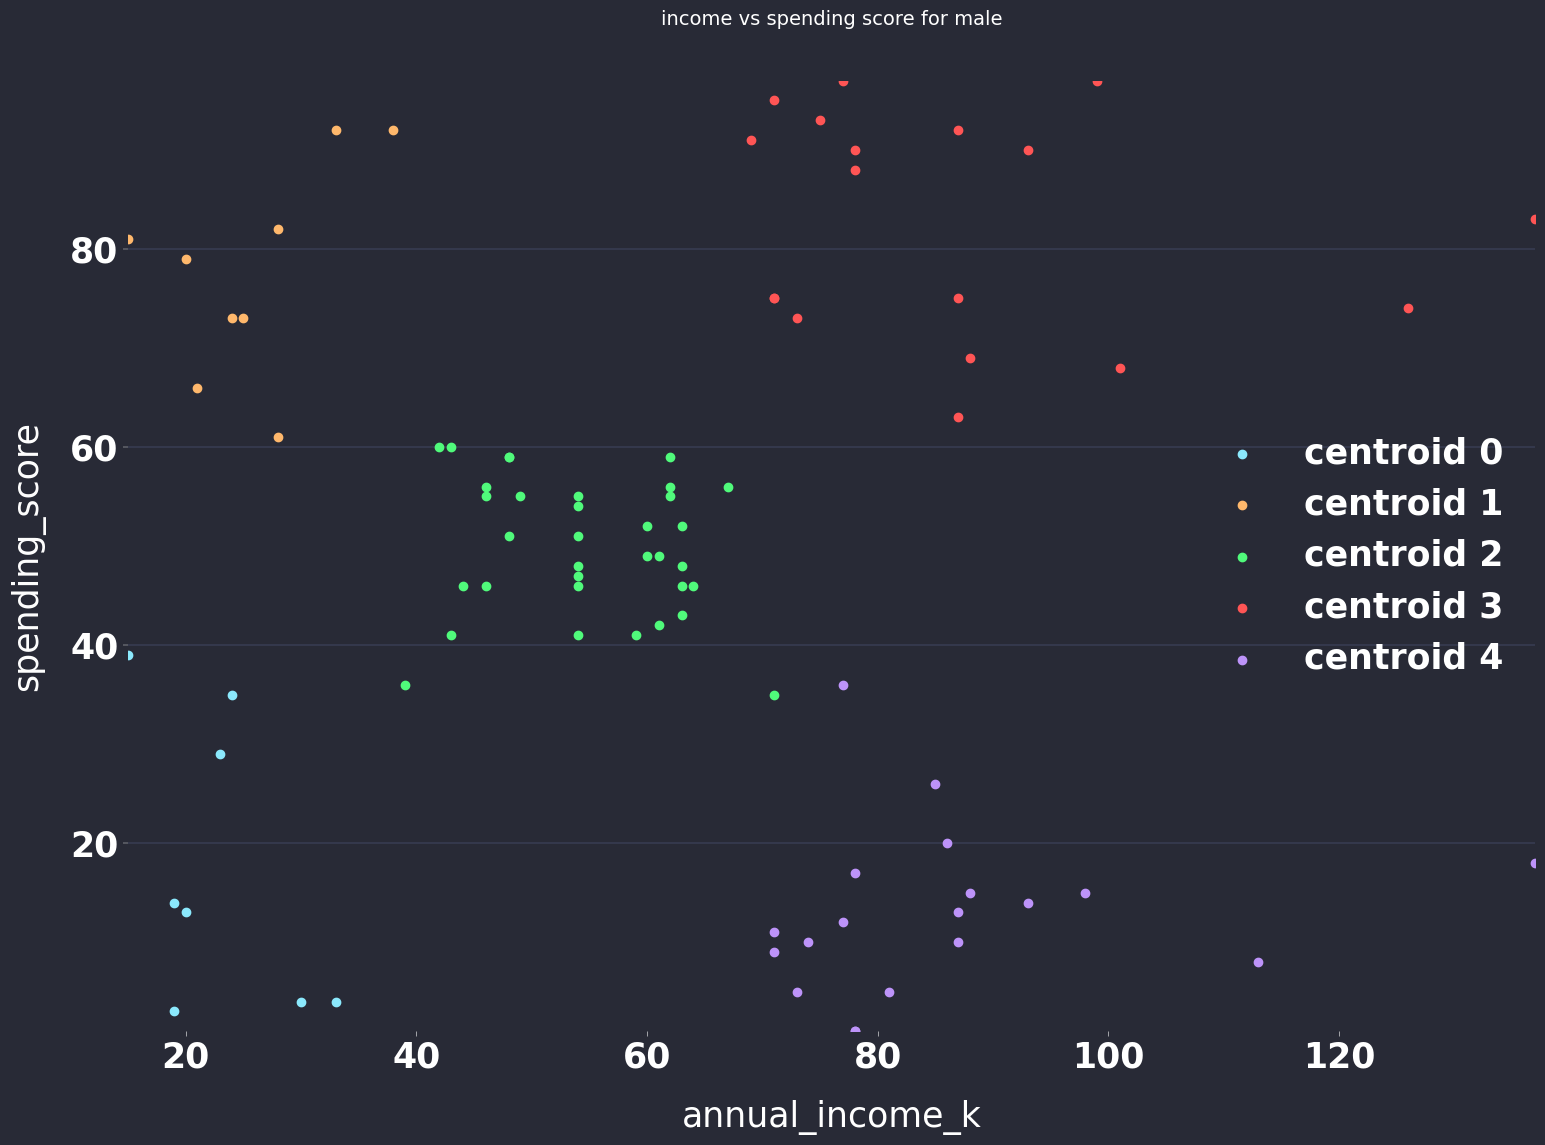

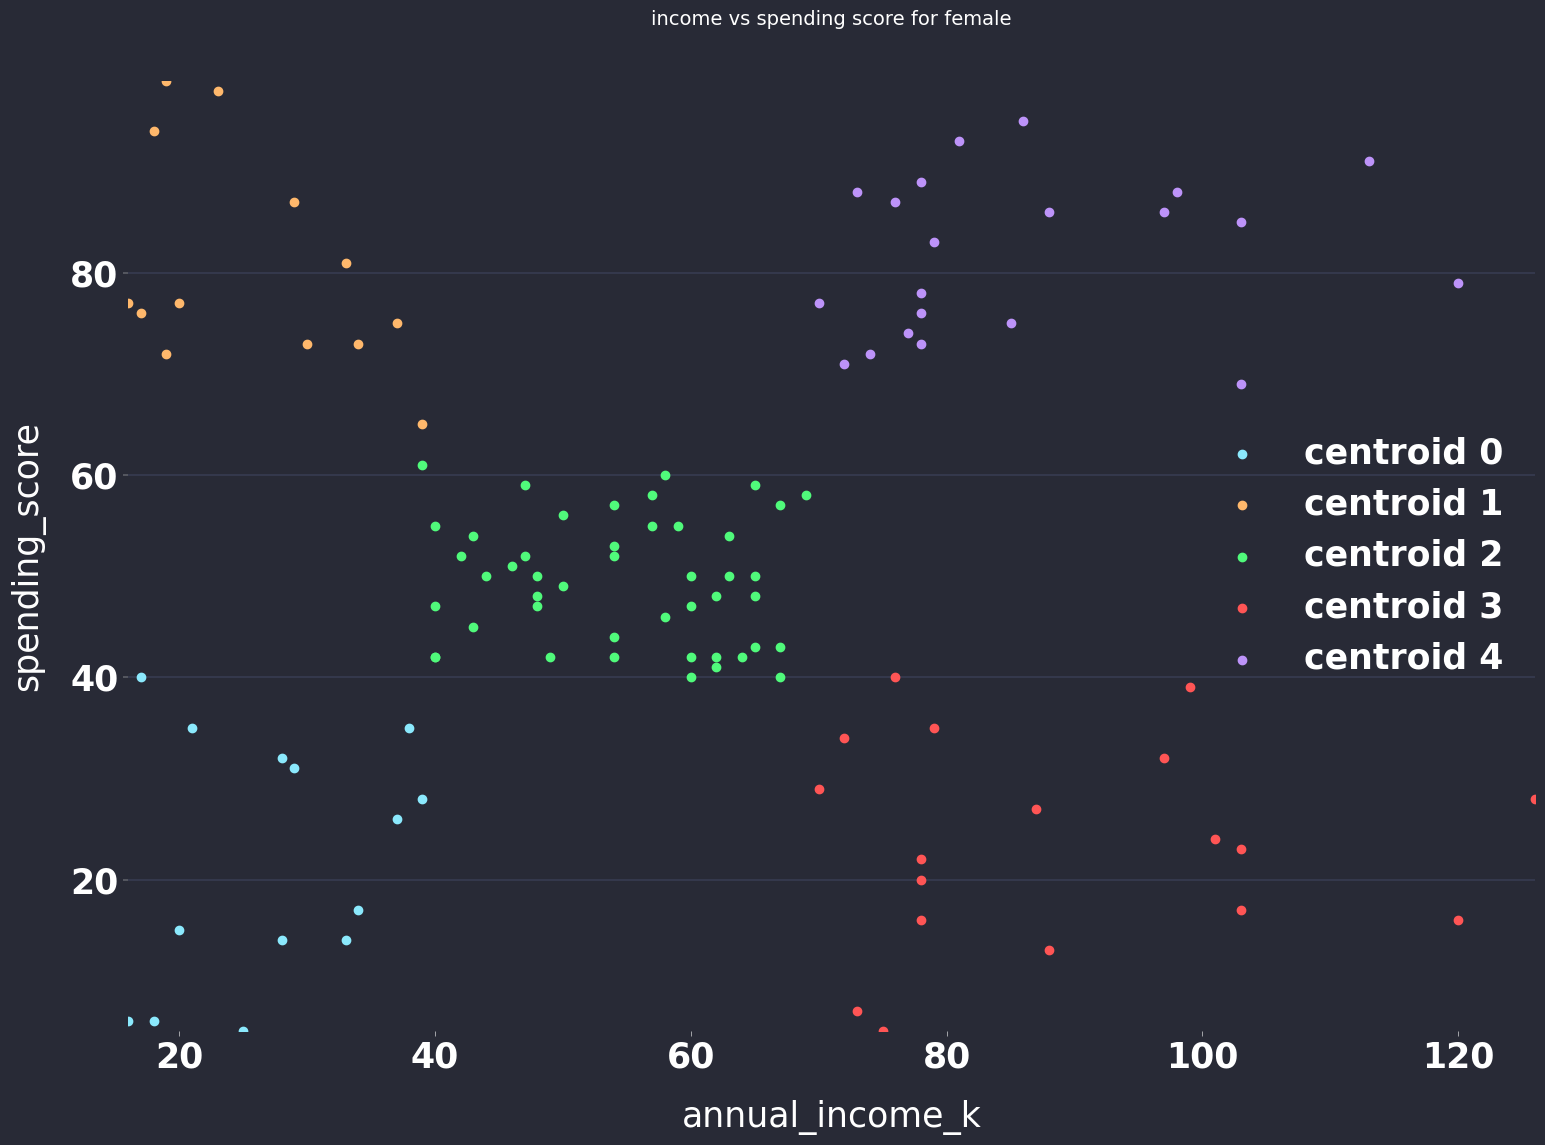

In [4]:
stats = {}
for gender_name, gender_df in {'male': m_df, 'female': f_df}.items():
    # Plot the graphs
    columns = ['age', 'annual_income_k', 'spending_score']
    centroid_x_vals = [-1, -0.2, 1, 1, -1]
    centroid_y_vals = [-1, 0, -1, 1, 1]
    sl.full_k_means(gender_df, 'annual_income_k', 'spending_score', centroid_x_vals, centroid_y_vals)
    pl.plot_centroid_groups(gender_df, 'annual_income_k', 'spending_score', f'income vs spending score for {gender_name}')
    # Compute stats
    gender_stats = gender_df.groupby('centroid_idx')[['annual_income_k', 'spending_score']].agg(['mean', 'median', 'std', 'min', 'max'])
    stats[gender_name] = gender_stats

In [6]:
stats['male']

annual_income_k                            spending_score         \
                        mean median        std min  max           mean median   
centroid_idx                                                                    
0                  22.875000   21.5   6.034129  15   33      17.625000   13.5   
1                  25.777778   25.0   6.960204  15   38      77.666667   79.0   
2                  54.735294   54.0   8.324148  39   71      49.852941   50.0   
3                  87.111111   82.5  18.929867  69  137      82.666667   85.5   
4                  85.894737   81.0  16.110365  71  137      12.947368   12.0   

                                 
                    std min max  
centroid_idx                     
0             14.676877   3  39  
1             10.606602  61  92  
2              6.858449  35  60  
3             11.103788  63  97  
4              8.422679   1  36

In [7]:
stats['female']

annual_income_k                            spending_score         \
                        mean median        std min  max           mean median   
centroid_idx                                                                    
0                  27.357143   28.0   8.063280  16   39      21.714286   21.5   
1                  25.692308   23.0   8.239990  16   39      80.538462   77.0   
2                  54.543478   55.5   9.064477  39   69      49.521739   50.0   
3                  89.055556   83.0  16.748915  70  126      23.722222   23.5   
4                  86.047619   79.0  14.157953  70  120      81.666667   83.0   

                                 
                    std min max  
centroid_idx                     
0             12.079408   5  40  
1             10.697472  65  99  
2              6.159867  40  61  
3             10.242963   5  40  
4              7.831560  69  95